# Experiment 3: Network Architecture Sweep

This notebook studies how neural-network depth and width affect the accuracy and computational cost of a Physics-Informed Neural Network for Burgers' equation.

The supervised and physics data sizes are fixed:

- `N_u = 100`
- `N_f = 5000`

Two architecture sweeps are performed:

### Depth sweep

The number of neurons is fixed at 20:

- 2 hidden layers × 20 neurons
- 4 hidden layers × 20 neurons
- 6 hidden layers × 20 neurons
- 8 hidden layers × 20 neurons

### Width sweep

The number of hidden layers is fixed at 8:

- 8 hidden layers × 10 neurons
- 8 hidden layers × 20 neurons
- 8 hidden layers × 40 neurons

The goal is to compare prediction accuracy, parameter count, and training time.

# Imports

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from scipy.stats import qmc

torch.set_default_dtype(torch.float64)

## Mount Google drive


In [2]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True

    print("Running in Google Colab.")
except ImportError:
    IN_COLAB = False

    print("Running in local Jupyter Notebook.")

Mounted at /content/drive
Running in Google Colab.


## Paths and ouput folders

In [3]:
if IN_COLAB:
    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/pinn-burgers-reproduction"
    )
else:
    # Assumes this notebook is inside the notebook/ folder
    PROJECT_ROOT = Path("..").resolve()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "burgers_shock.mat"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "experiment_3_architecture"
)

FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data file was not found:\n{DATA_PATH}\n"
        "Check PROJECT_ROOT and your Google Drive folder."
    )

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Results directory:", RESULTS_DIR)

Project root: /content/drive/MyDrive/pinn-burgers-reproduction
Data path: /content/drive/MyDrive/pinn-burgers-reproduction/data/burgers_shock.mat
Results directory: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_3_architecture


# Load reference solution

In [4]:
data = scipy.io.loadmat(DATA_PATH)

t_grid = data["t"].flatten()[:, None]
x_grid = data["x"].flatten()[:, None]
Exact = data["usol"]

X, T = np.meshgrid(
    x_grid.flatten(),
    t_grid.flatten()
)

# Complete evaluation grid in (t, x) order
X_star = np.hstack(
    (
        T.flatten()[:, None],
        X.flatten()[:, None]
    )
)

u_star = Exact.T.flatten()[:, None]

lb = X_star.min(axis=0)
ub = X_star.max(axis=0)

print("t_grid:", t_grid.shape)
print("x_grid:", x_grid.shape)
print("Exact:", Exact.shape)
print("X_star:", X_star.shape)
print("u_star:", u_star.shape)
print("Lower bounds:", lb)
print("Upper bounds:", ub)

t_grid: (100, 1)
x_grid: (256, 1)
Exact: (256, 100)
X_star: (25600, 2)
u_star: (25600, 1)
Lower bounds: [ 0. -1.]
Upper bounds: [0.99 1.  ]


# Experiment settings

In [6]:
N_u_FIXED = 100
N_f_FIXED = 5000

SEED = 1234

ADAM_STEPS = 2000
LBFGS_STEPS = 3000

PRINT_EVERY = 200

architecture_configs = [
    {
        "name": "2x20",
        "hidden_layers": 2,
        "neurons": 20,
        "group": "depth"
    },
    {
        "name": "4x20",
        "hidden_layers": 4,
        "neurons": 20,
        "group": "depth"
    },
    {
        "name": "6x20",
        "hidden_layers": 6,
        "neurons": 20,
        "group": "depth"
    },
    {
        "name": "8x20",
        "hidden_layers": 8,
        "neurons": 20,
        "group": "depth_and_width"
    },
    {
        "name": "8x10",
        "hidden_layers": 8,
        "neurons": 10,
        "group": "width"
    },
    {
        "name": "8x40",
        "hidden_layers": 8,
        "neurons": 40,
        "group": "width"
    }
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Fixed N_u:", N_u_FIXED)
print("Fixed N_f:", N_f_FIXED)

pd.DataFrame(architecture_configs)

Device: cuda
Fixed N_u: 100
Fixed N_f: 5000


,name,hidden_layers,neurons,group
0,2x20,2,20,depth
1,4x20,4,20,depth
2,6x20,6,20,depth
3,8x20,8,20,depth_and_width
4,8x10,8,10,width
5,8x40,8,40,width


## Random seed function

In [7]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# Prepare one fixed dataset

In [8]:
set_seed(SEED)

# Initial condition: t = 0
xx_initial = np.hstack(
    (
        X[0:1, :].T,
        T[0:1, :].T
    )
)

u_initial = Exact[:, 0:1]

# Left boundary: x = -1
xx_left = np.hstack(
    (
        X[:, 0:1],
        T[:, 0:1]
    )
)

u_left = Exact[0:1, :].T

# Right boundary: x = 1
xx_right = np.hstack(
    (
        X[:, -1:],
        T[:, -1:]
    )
)

u_right = Exact[-1:, :].T

# Combine all supervised data and reorder columns to (t, x)
X_u_all = np.vstack(
    (
        xx_initial,
        xx_left,
        xx_right
    )
)[:, [1, 0]]

u_all = np.vstack(
    (
        u_initial,
        u_left,
        u_right
    )
)

# Select the same N_u points for every architecture
rng = np.random.default_rng(SEED)

supervised_indices = rng.choice(
    X_u_all.shape[0],
    size=N_u_FIXED,
    replace=False
)

X_u_train = X_u_all[supervised_indices, :]
u_train = u_all[supervised_indices, :]

# Create one fixed set of collocation points
sampler = qmc.LatinHypercube(
    d=2,
    seed=SEED
)

sample = sampler.random(
    n=N_f_FIXED
)

X_f_train = lb + (ub - lb) * sample

print("Supervised inputs:", X_u_train.shape)
print("Supervised targets:", u_train.shape)
print("Collocation points:", X_f_train.shape)

Supervised inputs: (100, 2)
Supervised targets: (100, 1)
Collocation points: (5000, 2)


## Convert fixed data to tensors

In [9]:
def convert_to_tensors(
    X_u_train,
    u_train,
    X_f_train,
    device
):
    tensors = {}

    tensors["t_u"] = torch.tensor(
        X_u_train[:, 0:1],
        requires_grad=True,
        device=device
    )

    tensors["x_u"] = torch.tensor(
        X_u_train[:, 1:2],
        requires_grad=True,
        device=device
    )

    tensors["u_d"] = torch.tensor(
        u_train,
        device=device
    )

    tensors["t_f"] = torch.tensor(
        X_f_train[:, 0:1],
        requires_grad=True,
        device=device
    )

    tensors["x_f"] = torch.tensor(
        X_f_train[:, 1:2],
        requires_grad=True,
        device=device
    )

    return tensors


training_tensors = convert_to_tensors(
    X_u_train=X_u_train,
    u_train=u_train,
    X_f_train=X_f_train,
    device=device
)

print("Tensor conversion complete.")

Tensor conversion complete.


# Build a layer list

In [10]:
def build_layers(hidden_layers, neurons):
    """
    Example:
    hidden_layers = 4
    neurons = 20

    Result:
    [2, 20, 20, 20, 20, 1]
    """

    return (
        [2]
        + [neurons] * hidden_layers
        + [1]
    )


for config in architecture_configs:
    config_layers = build_layers(
        hidden_layers=config["hidden_layers"],
        neurons=config["neurons"]
    )

    print(config["name"], "->", config_layers)

2x20 -> [2, 20, 20, 1]
4x20 -> [2, 20, 20, 20, 20, 1]
6x20 -> [2, 20, 20, 20, 20, 20, 20, 1]
8x20 -> [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
8x10 -> [2, 10, 10, 10, 10, 10, 10, 10, 10, 1]
8x40 -> [2, 40, 40, 40, 40, 40, 40, 40, 40, 1]


# PINN model

In [11]:
class PINN(nn.Module):
    def __init__(self, layers, lb, ub):
        super().__init__()

        self.register_buffer(
            "lb_t",
            torch.tensor(lb)
        )

        self.register_buffer(
            "ub_t",
            torch.tensor(ub)
        )

        self.linears = nn.ModuleList(
            [
                nn.Linear(
                    layers[i],
                    layers[i + 1]
                )
                for i in range(len(layers) - 1)
            ]
        )

        for layer in self.linears:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, t, x):
        inputs = torch.cat(
            (t, x),
            dim=1
        )

        hidden = (
            2.0 * (inputs - self.lb_t)
            / (self.ub_t - self.lb_t)
            - 1.0
        )

        for layer in self.linears[:-1]:
            hidden = torch.tanh(
                layer(hidden)
            )

        output = self.linears[-1](hidden)

        return output

# Burgers equation residual

In [12]:
def net_f(model, t, x):
    u = model(t, x)

    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    residual = (
        u_t
        + u * u_x
        - (0.01 / np.pi) * u_xx
    )

    return residual

# Evaluation metrics

In [13]:
def relative_l2_error(y_true, y_pred):
    numerator = np.linalg.norm(
        y_true - y_pred,
        ord=2
    )

    denominator = np.linalg.norm(
        y_true,
        ord=2
    )

    return numerator / denominator


def maximum_absolute_error(y_true, y_pred):
    return np.max(
        np.abs(y_true - y_pred)
    )

# Run one architecture

In [14]:
def run_experiment(config):
    name = config["name"]
    hidden_layers = config["hidden_layers"]
    neurons = config["neurons"]

    print("=" * 70)
    print(f"Running architecture: {name}")
    print(
        f"Hidden layers: {hidden_layers}, "
        f"neurons per layer: {neurons}"
    )
    print("=" * 70)

    set_seed(SEED)

    start_time = time.time()

    layers = build_layers(
        hidden_layers=hidden_layers,
        neurons=neurons
    )

    model = PINN(
        layers=layers,
        lb=lb,
        ub=ub
    ).to(device)

    num_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    def loss_fn():
        u_prediction = model(
            training_tensors["t_u"],
            training_tensors["x_u"]
        )

        mse_u = torch.mean(
            (
                training_tensors["u_d"]
                - u_prediction
            ) ** 2
        )

        f_prediction = net_f(
            model,
            training_tensors["t_f"],
            training_tensors["x_f"]
        )

        mse_f = torch.mean(
            f_prediction ** 2
        )

        total_loss = mse_u + mse_f

        return total_loss, mse_u, mse_f

    # Adam
    optimizer_adam = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for iteration in range(ADAM_STEPS):
        optimizer_adam.zero_grad()

        loss, mse_u, mse_f = loss_fn()

        loss.backward()
        optimizer_adam.step()

        if iteration % PRINT_EVERY == 0:
            print(
                f"Adam {iteration:5d} | "
                f"loss={loss.item():.3e} | "
                f"mse_u={mse_u.item():.3e} | "
                f"mse_f={mse_f.item():.3e}"
            )

    # L-BFGS
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=LBFGS_STEPS,
        max_eval=LBFGS_STEPS + 500,
        history_size=50,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe"
    )

    lbfgs_counter = [0]

    def closure():
        optimizer_lbfgs.zero_grad()

        loss, mse_u, mse_f = loss_fn()

        loss.backward()

        lbfgs_counter[0] += 1

        if lbfgs_counter[0] % PRINT_EVERY == 0:
            print(
                f"L-BFGS {lbfgs_counter[0]:5d} | "
                f"loss={loss.item():.3e} | "
                f"mse_u={mse_u.item():.3e} | "
                f"mse_f={mse_f.item():.3e}"
            )

        return loss

    optimizer_lbfgs.step(closure)

    # Evaluation
    with torch.no_grad():
        t_test = torch.tensor(
            X_star[:, 0:1],
            device=device
        )

        x_test = torch.tensor(
            X_star[:, 1:2],
            device=device
        )

        u_pred = (
            model(t_test, x_test)
            .detach()
            .cpu()
            .numpy()
        )

    relative_error = relative_l2_error(
        u_star,
        u_pred
    )

    max_error = maximum_absolute_error(
        u_star,
        u_pred
    )

    final_loss, final_mse_u, final_mse_f = loss_fn()

    training_time = time.time() - start_time

    model_path = MODELS_DIR / f"{name}.pt"

    torch.save(
        model.state_dict(),
        model_path
    )

    result = {
        "name": name,
        "group": config["group"],
        "hidden_layers": hidden_layers,
        "neurons": neurons,
        "N_u": N_u_FIXED,
        "N_f": N_f_FIXED,
        "num_parameters": num_parameters,
        "relative_l2_error": relative_error,
        "max_absolute_error": max_error,
        "final_total_loss": final_loss.item(),
        "final_mse_u": final_mse_u.item(),
        "final_mse_f": final_mse_f.item(),
        "training_time_seconds": training_time,
        "device": str(device)
    }

    print("Finished:")
    print(result)
    print("Saved model to:", model_path)

    return result

# Run sweep

In [15]:
results_path = (
    RESULTS_DIR
    / "architecture_sweep_results.csv"
)

if results_path.exists():
    existing_results = pd.read_csv(
        results_path
    )

    results = existing_results.to_dict(
        orient="records"
    )

    completed_names = set(
        existing_results["name"]
    )

    print("Loaded existing results.")
    print("Completed:", completed_names)
else:
    results = []
    completed_names = set()

for config in architecture_configs:
    name = config["name"]

    if name in completed_names:
        print(f"Skipping completed architecture: {name}")
        continue

    result = run_experiment(config)

    results.append(result)
    completed_names.add(name)

    df_results = pd.DataFrame(results)

    df_results.to_csv(
        results_path,
        index=False
    )

    print("Saved current results to:", results_path)

df_results = pd.DataFrame(results)

df_results

Running architecture: 2x20
Hidden layers: 2, neurons per layer: 20


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam     0 | loss=2.236e+00 | mse_u=6.722e-01 | mse_f=1.564e+00
Adam   200 | loss=2.581e-01 | mse_u=2.494e-01 | mse_f=8.706e-03
Adam   400 | loss=2.393e-01 | mse_u=2.270e-01 | mse_f=1.233e-02
Adam   600 | loss=1.519e-01 | mse_u=1.300e-01 | mse_f=2.199e-02
Adam   800 | loss=1.230e-01 | mse_u=8.468e-02 | mse_f=3.834e-02
Adam  1000 | loss=1.134e-01 | mse_u=7.987e-02 | mse_f=3.354e-02
Adam  1200 | loss=1.052e-01 | mse_u=7.307e-02 | mse_f=3.209e-02
Adam  1400 | loss=9.884e-02 | mse_u=6.815e-02 | mse_f=3.069e-02
Adam  1600 | loss=9.359e-02 | mse_u=6.408e-02 | mse_f=2.951e-02
Adam  1800 | loss=8.930e-02 | mse_u=6.079e-02 | mse_f=2.850e-02
L-BFGS   200 | loss=5.474e-02 | mse_u=3.743e-02 | mse_f=1.730e-02
L-BFGS   400 | loss=3.049e-02 | mse_u=1.982e-02 | mse_f=1.067e-02
L-BFGS   600 | loss=2.426e-02 | mse_u=1.632e-02 | mse_f=7.938e-03
L-BFGS   800 | loss=2.180e-02 | mse_u=1.374e-02 | mse_f=8.066e-03
L-BFGS  1000 | loss=1.913e-02 | mse_u=1.274e-02 | mse_f=6.389e-03
L-BFGS  1200 | loss=1.400e-02 

,name,group,hidden_layers,neurons,N_u,N_f,num_parameters,relative_l2_error,max_absolute_error,final_total_loss,final_mse_u,final_mse_f,training_time_seconds,device
0,2x20,depth,2,20,100,5000,501,0.098022,1.044543,0.001514,6.038572e-04,0.000910,64.243022,cuda
1,4x20,depth,4,20,100,5000,1341,0.040149,0.447694,0.000034,9.964430e-06,0.000024,80.588225,cuda
2,6x20,depth,6,20,100,5000,2181,0.154132,1.435164,0.000024,3.852235e-06,0.000020,107.789666,cuda
3,8x20,depth_and_width,8,20,100,5000,3021,0.008071,0.079145,0.000005,3.982234e-07,0.000004,131.591115,cuda
4,8x10,width,8,10,100,5000,811,0.018683,0.200704,0.000016,1.707341e-06,0.000014,118.476050,cuda
5,8x40,width,8,40,100,5000,11641,0.000748,0.008439,0.000002,1.516390e-07,0.000002,161.143816,cuda


# Summary table

In [16]:
summary_columns = [
    "name",
    "hidden_layers",
    "neurons",
    "num_parameters",
    "relative_l2_error",
    "max_absolute_error",
    "final_mse_u",
    "final_mse_f",
    "training_time_seconds",
    "device"
]

df_summary = (
    df_results[summary_columns]
    .sort_values(
        [
            "hidden_layers",
            "neurons"
        ]
    )
    .reset_index(drop=True)
)

summary_path = (
    TABLES_DIR
    / "architecture_sweep_summary.csv"
)

df_summary.to_csv(
    summary_path,
    index=False
)

df_summary

,name,hidden_layers,neurons,num_parameters,relative_l2_error,max_absolute_error,final_mse_u,final_mse_f,training_time_seconds,device
0,2x20,2,20,501,0.098022,1.044543,6.038572e-04,0.000910,64.243022,cuda
1,4x20,4,20,1341,0.040149,0.447694,9.964430e-06,0.000024,80.588225,cuda
2,6x20,6,20,2181,0.154132,1.435164,3.852235e-06,0.000020,107.789666,cuda
3,8x10,8,10,811,0.018683,0.200704,1.707341e-06,0.000014,118.476050,cuda
4,8x20,8,20,3021,0.008071,0.079145,3.982234e-07,0.000004,131.591115,cuda
5,8x40,8,40,11641,0.000748,0.008439,1.516390e-07,0.000002,161.143816,cuda


# Depth vs relative L2 error

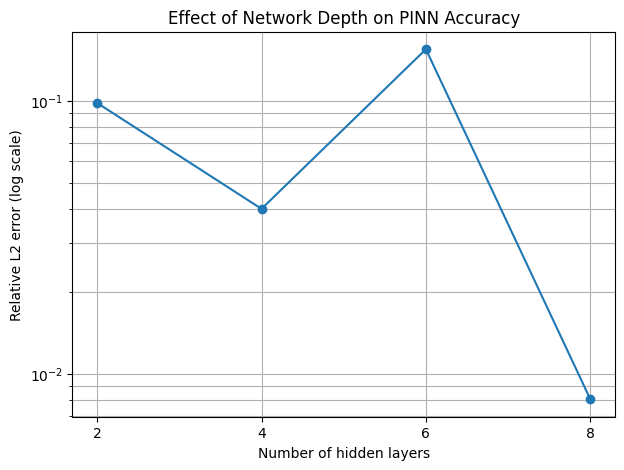

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_3_architecture/figures/depth_vs_relative_l2_log.png


In [17]:
df_depth = (
    df_results[
        df_results["neurons"] == 20
    ]
    .sort_values("hidden_layers")
)

plt.figure(figsize=(7, 5))

plt.plot(
    df_depth["hidden_layers"],
    df_depth["relative_l2_error"],
    marker="o"
)

plt.yscale("log")

plt.xticks(
    df_depth["hidden_layers"]
)

plt.xlabel("Number of hidden layers")
plt.ylabel("Relative L2 error (log scale)")
plt.title("Effect of Network Depth on PINN Accuracy")
plt.grid(True, which="both")

figure_path = (
    FIGURES_DIR
    / "depth_vs_relative_l2_log.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Width vs relative L2 error

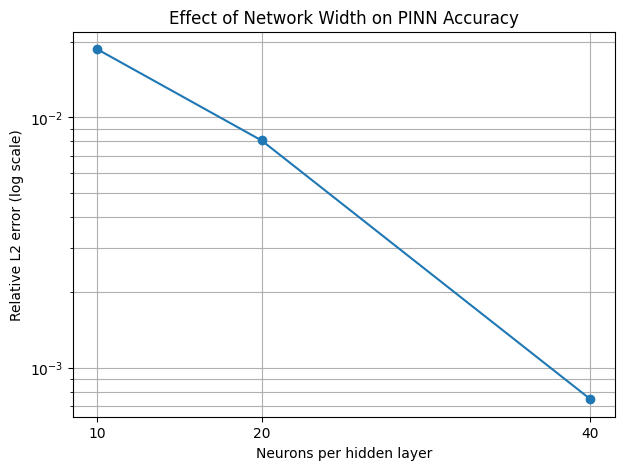

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_3_architecture/figures/width_vs_relative_l2_log.png


In [18]:
df_width = (
    df_results[
        df_results["hidden_layers"] == 8
    ]
    .sort_values("neurons")
)

plt.figure(figsize=(7, 5))

plt.plot(
    df_width["neurons"],
    df_width["relative_l2_error"],
    marker="o"
)

plt.yscale("log")

plt.xticks(
    df_width["neurons"]
)

plt.xlabel("Neurons per hidden layer")
plt.ylabel("Relative L2 error (log scale)")
plt.title("Effect of Network Width on PINN Accuracy")
plt.grid(True, which="both")

figure_path = (
    FIGURES_DIR
    / "width_vs_relative_l2_log.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Parameter count vs error

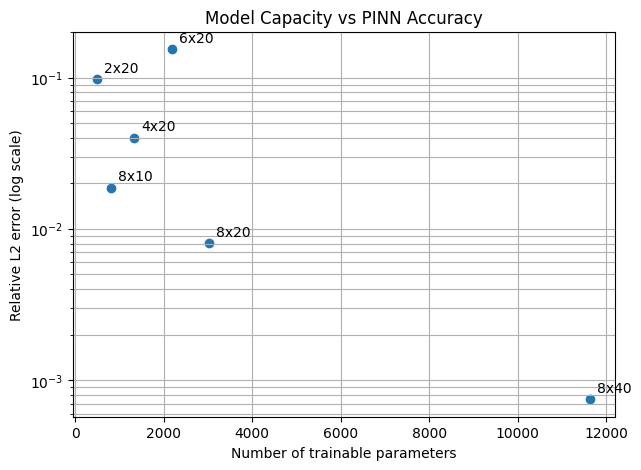

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_3_architecture/figures/parameters_vs_relative_l2.png


In [19]:
df_plot = df_results.sort_values(
    "num_parameters"
)

plt.figure(figsize=(7, 5))

plt.scatter(
    df_plot["num_parameters"],
    df_plot["relative_l2_error"]
)

for _, row in df_plot.iterrows():
    plt.annotate(
        row["name"],
        (
            row["num_parameters"],
            row["relative_l2_error"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.yscale("log")

plt.xlabel("Number of trainable parameters")
plt.ylabel("Relative L2 error (log scale)")
plt.title("Model Capacity vs PINN Accuracy")
plt.grid(True, which="both")

figure_path = (
    FIGURES_DIR
    / "parameters_vs_relative_l2.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Parameter count vs training time

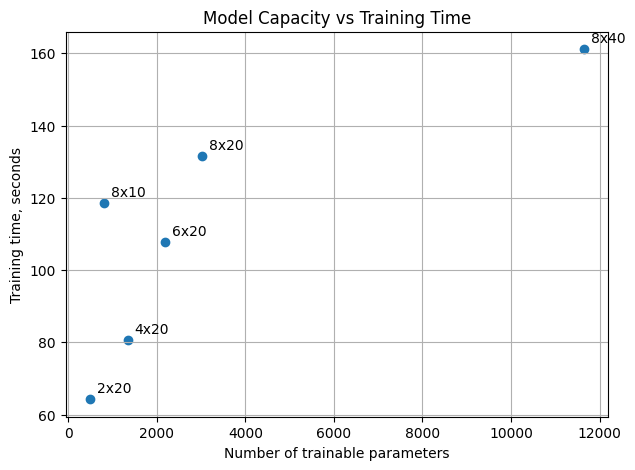

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_3_architecture/figures/parameters_vs_training_time.png


In [20]:
df_plot = df_results.sort_values(
    "num_parameters"
)

plt.figure(figsize=(7, 5))

plt.scatter(
    df_plot["num_parameters"],
    df_plot["training_time_seconds"]
)

for _, row in df_plot.iterrows():
    plt.annotate(
        row["name"],
        (
            row["num_parameters"],
            row["training_time_seconds"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Number of trainable parameters")
plt.ylabel("Training time, seconds")
plt.title("Model Capacity vs Training Time")
plt.grid(True)

figure_path = (
    FIGURES_DIR
    / "parameters_vs_training_time.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Best architecture

In [21]:
best_row = df_results.loc[
    df_results["relative_l2_error"].idxmin()
]

print("Best architecture:")
print(best_row)

Best architecture:
name                           8x40
group                         width
hidden_layers                     8
neurons                          40
N_u                             100
N_f                            5000
num_parameters                11641
relative_l2_error          0.000748
max_absolute_error         0.008439
final_total_loss           0.000002
final_mse_u                     0.0
final_mse_f                0.000002
training_time_seconds    161.143816
device                         cuda
Name: 5, dtype: object


# Conclusion

This experiment studied how network depth and width affect PINN accuracy and computational cost.

The supervised data size was fixed at `N_u = 100`, and the number of collocation points was fixed at `N_f = 5000`. All architectures used the same supervised and collocation points.

### Effect of depth

The depth sweep produced the following relative L2 errors:

- `2 × 20`: `0.0980`
- `4 × 20`: `0.0401`
- `6 × 20`: `0.1541`
- `8 × 20`: `0.00807`

Increasing depth did not produce a perfectly monotonic improvement. The `6 × 20` model performed worse than the shallower models, despite achieving a relatively low training loss. This indicates that PINN optimization can converge to a solution that satisfies the sampled training constraints but generalizes poorly across the complete domain.

The `8 × 20` model achieved the best result in the depth sweep and was about 12 times more accurate than the `2 × 20` model.

### Effect of width

The width sweep produced the following relative L2 errors:

- `8 × 10`: `0.0187`
- `8 × 20`: `0.00807`
- `8 × 40`: `0.000748`

Increasing network width produced a clear and consistent improvement. The `8 × 40` model was approximately 25 times more accurate than the `8 × 10` model and approximately 10.8 times more accurate than the `8 × 20` model.

The `8 × 40` architecture achieved the best overall result, with a relative L2 error of `7.48 × 10⁻⁴` and a maximum absolute error of `0.00844`.

Training time increased with model size, from approximately 64 seconds for the smallest network to 161 seconds for the largest network. However, the accuracy improvement of the wider model was much larger than the increase in training time.

Overall, the experiment shows that sufficient model capacity is important for representing the sharp nonlinear solution of Burgers' equation. Under these settings, increasing width was more reliable than increasing depth.